c:\Users\kaiol\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\kaiol\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## Relação Sala-Público (1971 - 2024)

#### Dados retirados do Filme B (1971 - 2018)

Cria um objeto de configuração para o navegador Chrome. Isso serve para a inserção de regras (como rodar o navegador em segundo plano sem abrir a janela, definir o tamanho da tela, etc.) que o Selenium utiliza para fazer o scraping da tabela.

,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
0,--> Busca Em todos os anos 2017 2016 2015 ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Busca Em todos os anos 2017 2016 2015 2014 ...,NaN,Menu,NaN,Imprimir,NaN,Anterior,NaN,Próximo,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,Database Brasil 2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,25. Histórico de salas e público (1971/2018),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,anosalaspúblicomédia por sala19712.154203.020....,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,ano,salas,público,média por sala,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1971,2.154,203.020.339,94.253,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1972,2.648,191.489.250,72.315,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.to_csv('sala_publico_71_18.csv', index=False)

O comando .iloc serve para "recortar" a tabela com base na posição numérica das linhas e colunas.

- **8:56 (Linhas)**: Ele seleciona apenas as linhas da posição 8 até a 55. Geralmente, fazemos isso no web scraping para pular cabeçalhos sujos do site (linhas 0 a 7) e ignorar os rodapés (tudo a partir da linha 56).

- **0:4 (Colunas)**: Ele seleciona apenas as primeiras 4 colunas da tabela (posições 0, 1, 2 e 3).

Renomeia-se as colunas para nomes descritivos.

In [4]:
df = df.iloc[8:56, 0:4]

df.rename(columns = {0:'Ano',
                    1:'Salas',
                    2:'Público',
                    3:'Média por Sala'}, inplace=True)

In [5]:
df

,Ano,Salas,Público,Média por Sala
8,1971,2.154,203.020.339,94.253
9,1972,2.648,191.489.250,72.315
10,1973,2.690,193.377.651,71.888
11,1974,2.676,201.291.002,75.221
12,1975,3.276,275.380.446,84.060
13,1976,3.161,250.530.851,79.257
14,1977,3.156,208.336.002,66.013
15,1978,2.973,211.657.024,71.193
16,1979,2.937,191.908.000,65.342
17,1980,2.365,164.773.000,69.671


Converte os dados númericos, que eram do tipo string, para int.

In [6]:
df['Ano'] = df['Ano'].str.replace('.', '').astype(int)
df['Público'] = df['Público'].str.replace('.', '').astype(int)
df['Salas'] = df['Salas'].str.replace('.', '').astype(int)
df['Média por Sala'] = df['Média por Sala'].str.replace('.', '').astype(int)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 8 to 55
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Ano             48 non-null     int32
 1   Salas           48 non-null     int32
 2   Público         48 non-null     int32
 3   Média por Sala  48 non-null     int32
dtypes: int32(4)
memory usage: 900.0 bytes


Define os valores do index do dataframe como os anos.

In [7]:
df.set_index(['Ano'], inplace=True)

In [8]:
df_incompleto = df
df_incompleto

,Salas,Público,Média por Sala
Ano,,,
1971,2154,203020339,94253
1972,2648,191489250,72315
1973,2690,193377651,71888
1974,2676,201291002,75221
1975,3276,275380446,84060
1976,3161,250530851,79257
1977,3156,208336002,66013
1978,2973,211657024,71193
1979,2937,191908000,65342


#### Dados retirados do anuário da Ancine (2019 - 2024)

Utilizamos a biblioteca **pdfplumber** para pegar a tabela que contém as informações gerais do cinema brasileiro no período de 2015 a 2024.

Usamos a função *.pages* para pegar a página que contém essa tabela e *.extract_table* para extraí-la do pdf.

In [23]:
import pdfplumber

with pdfplumber.open("anuario-do-audiovisual-brasileiro-2024.pdf") as pdf:
    primeira_pagina = pdf.pages[12]
    texto = primeira_pagina.extract_table()
    df = pd.DataFrame(texto)

df.to_csv('sala_publico_15_24.csv', index=False)
df

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,Indicadores,NaN,NaN,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
1,Público,NaN,NaN,173.022.827,184.327.360,181.226.407,163.454.506,177.719.156,39.437.397,52.267.327,95.287.334,114.076.575,125.256.490
2,Renda (R$),NaN,NaN,2.351.590.807,2.599.327.628,2.717.664.735,2.458.271.967,2.809.994.860,628.681.962,913.669.053,1.819.558.008,2.237.076.190,2.490.285.189
3,Títulos lançados,NaN,NaN,455,458,463,472,452,174,309,385,415,456
4,,Preço Médio do,,14,14,15,15,16,16,17,19,20,20
5,NaN,Ingresso (R$),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,,Complexos em,,742,771,782,809,852,466,766,812,841,866
7,NaN,funcionamento,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,,Salas em,,3.005,3.160,3.223,3.347,3.507,1.860,3.266,3.415,3.468,3.510
9,NaN,funcionamento,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Esse processo de extração gera dados nulos, no entanto, isso não corresponde em dados faltantes em relação a tabela original, é apenas um erro genérico que ocorre ao fazer isso.

Dentro desse dataframe, queremos as informações relativas aos anos, quantidade de salas e público. Esses dados estão localizados nos indices **0, 1 e 8**. Portanto, usamos o *.loc* para fazermos a seleção das linhas por meio do índice, e o *.dropna(axis = 1)* para excluirmos os dados vazios nessas linhas.

Além disso, excluímos a coluna que indicava as informações que cada linha possuía.

In [10]:
dados_adicionais = df.loc[[0, 1, 8]].dropna(axis=1)
dados_adicionais.drop(columns=0, inplace=True)
dados_adicionais

,3,4,5,6,7,8,9,10,11,12
0,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
1,173.022.827,184.327.360,181.226.407,163.454.506,177.719.156,39.437.397,52.267.327,95.287.334,114.076.575,125.256.490
8,3.005,3.160,3.223,3.347,3.507,1.860,3.266,3.415,3.468,3.510


In [11]:
dados_adicionais = dados_adicionais.iloc[:, 4:12]
dados_adicionais

,7,8,9,10,11,12
0,2019,2020,2021,2022,2023,2024
1,177.719.156,39.437.397,52.267.327,95.287.334,114.076.575,125.256.490
8,3.507,1.860,3.266,3.415,3.468,3.510


Ao verificar a tipagem dos dados, vemos que todas as linhas são *object*, e, para o que faremos com esses dados, é essencial que eles sejam numéricos.

In [12]:
dados_adicionais.info()

<class 'pandas.DataFrame'>
Index: 3 entries, 0 to 8
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   7       3 non-null      str  
 1   8       3 non-null      str  
 2   9       3 non-null      str  
 3   10      3 non-null      str  
 4   11      3 non-null      str  
 5   12      3 non-null      str  
dtypes: str(6)
memory usage: 291.0 bytes


Fazemos a transposição do dataframe e definimos os nomes das colunas com suas informações relativas. 

Isso possibilita uma melhor leitura dos dados e uma maior facilidade na construção de gráficos. Além disso, é necessário transpôr a linha relativas aos anos, pois ela será o novo índice do nosso dataframe.

In [13]:
dados_adicionais = dados_adicionais.transpose()
dados_adicionais.columns = ['Ano', 'Público', 'Salas']
dados_adicionais = dados_adicionais[['Ano', 'Salas', 'Público']]
dados_adicionais

,Ano,Salas,Público
7,2019,3.507,177.719.156
8,2020,1.860,39.437.397
9,2021,3.266,52.267.327
10,2022,3.415,95.287.334
11,2023,3.468,114.076.575
12,2024,3.510,125.256.490


Nessa seção convertemos o tipo dos dados de *object* para *int*.

A função *.astype(int)* só consegue converter dados se eles não tiverem qualquer tipo de símbolos, isso significa que para as colunas *ano* e *público* é necessária a retirada dos pontos entre os números.

In [14]:
dados_adicionais['Ano'] = dados_adicionais['Ano'].str.replace('.', '').astype(int)
dados_adicionais['Público'] = dados_adicionais['Público'].str.replace('.', '').astype(int)
dados_adicionais['Salas'] = dados_adicionais['Salas'].str.replace('.', '').astype(int)

dados_adicionais.info()

<class 'pandas.DataFrame'>
Index: 6 entries, 7 to 12
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Ano      6 non-null      int32
 1   Salas    6 non-null      int32
 2   Público  6 non-null      int32
dtypes: int32(3)
memory usage: 292.0 bytes


Define-se *ano* como índice do dataframe.

In [15]:
dados_adicionais.set_index('Ano', inplace=True)

Cria-se a coluna *media*, relativa à média entre o total de público e salas em cada ano.

In [16]:
dados_adicionais['Média por Sala'] = round((dados_adicionais['Público'] / dados_adicionais['Salas']), 0)
dados_adicionais

,Salas,Público,Média por Sala
Ano,,,
2019,3507,177719156,50676.0
2020,1860,39437397,21203.0
2021,3266,52267327,16003.0
2022,3415,95287334,27903.0
2023,3468,114076575,32894.0
2024,3510,125256490,35686.0


Seleciona-se somente os dados relativos aos anos entre 2019 e 2024.

In [17]:
dados_adicionais = dados_adicionais.loc[[x for x in range(2019, 2025)]]
dados_adicionais

,Salas,Público,Média por Sala
Ano,,,
2019,3507,177719156,50676.0
2020,1860,39437397,21203.0
2021,3266,52267327,16003.0
2022,3415,95287334,27903.0
2023,3468,114076575,32894.0
2024,3510,125256490,35686.0


Concatenamos os dataframes que pegamos do **Filme B** e do **Anuário da Ancine**.

In [18]:
df = pd.concat([df_incompleto, dados_adicionais], axis=0)
df = df.reset_index()
df.to_csv('relacao_sala_publico.csv', index=False)
df

,Ano,Salas,Público,Média por Sala
0,1971,2154,203020339,94253.0
1,1972,2648,191489250,72315.0
2,1973,2690,193377651,71888.0
3,1974,2676,201291002,75221.0
4,1975,3276,275380446,84060.0
5,1976,3161,250530851,79257.0
6,1977,3156,208336002,66013.0
7,1978,2973,211657024,71193.0
8,1979,2937,191908000,65342.0
9,1980,2365,164773000,69671.0


In [19]:
df.set_index('Ano', inplace=True)
df

,Salas,Público,Média por Sala
Ano,,,
1971,2154,203020339,94253.0
1972,2648,191489250,72315.0
1973,2690,193377651,71888.0
1974,2676,201291002,75221.0
1975,3276,275380446,84060.0
1976,3161,250530851,79257.0
1977,3156,208336002,66013.0
1978,2973,211657024,71193.0
1979,2937,191908000,65342.0


#### Visualização temporária dos dados

In [20]:
import matplotlib.pyplot as plt

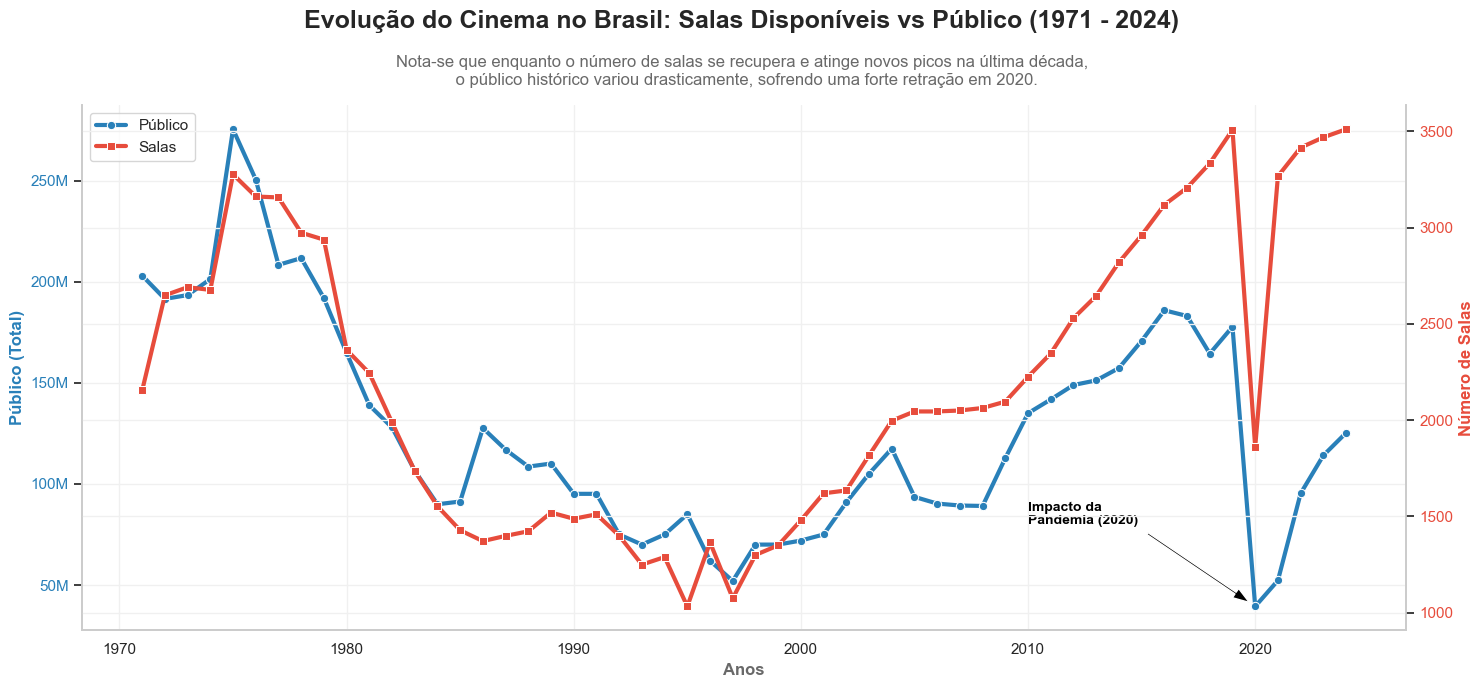

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

sns.set_theme(style="whitegrid", rc={"axes.facecolor": "#ffffff", 'grid.color': '#f0f0f0'})

fig, ax1 = plt.subplots(figsize=(15, 7))

color1 = '#2980b9' 
color2 = '#e74c3c' 

ax1.set_xlabel('Anos', fontsize=12, fontweight='bold', color='dimgrey')

ax1.set_ylabel('Público (Total)', fontsize=12, fontweight='bold', color=color1)
sns.lineplot(data=df, x=df.index, y='Público', color=color1, linewidth=3, marker='o', label='Público', ax=ax1)
ax1.tick_params(axis='y', labelcolor=color1)

def formatar_milhoes(x, pos):
    return f'{x * 1e-6:,.0f}M'
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(formatar_milhoes))

ax2 = ax1.twinx()  
ax2.set_ylabel('Número de Salas', fontsize=12, fontweight='bold', color=color2)
sns.lineplot(data=df, x=df.index, y='Salas', color=color2, linewidth=3, marker='s', label='Salas', ax=ax2)
ax2.tick_params(axis='y', labelcolor=color2)

ax1.annotate('Impacto da\nPandemia (2020)', 
             xy=(2020, 39437397), 
             xytext=(2010, 80000000),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
             fontsize=10, fontweight='bold', color='black')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', frameon=True, fontsize=11)
ax2.get_legend().remove()

plt.suptitle('Evolução do Cinema no Brasil: Salas Disponíveis vs Público (1971 - 2024)', 
             fontsize=18, fontweight='bold', y=0.98, x=0.5)
plt.title('Nota-se que enquanto o número de salas se recupera e atinge novos picos na última década, \n o público histórico variou drasticamente, sofrendo uma forte retração em 2020.', 
          fontsize=12, color='dimgrey', pad=15)

sns.despine(ax=ax1, right=False, left=False, top=True)
sns.despine(ax=ax2, right=False, left=False, top=True)

plt.tight_layout()
plt.show()